## Preparing data for modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv(r'C:\Users\grzeg\Portfolio\Credit-Risk-Prediction\south_german_credit\data\South German Credit.asc', delimiter = ' ')

In [3]:
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [4]:
df['credit_risk'] = df['credit_risk'].map({0:1, 1:0})

In [5]:
df['credit_risk'].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [6]:
df['amount'] = np.log(df['amount'])

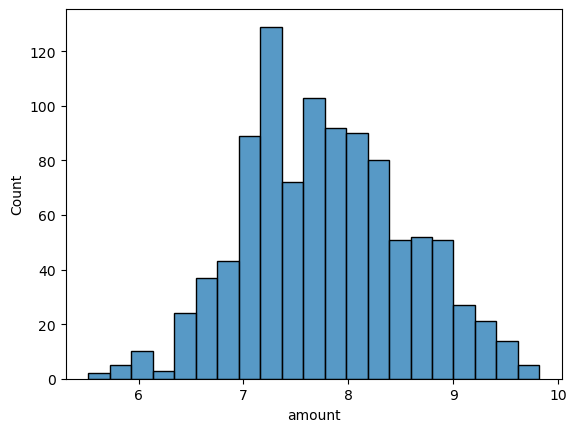

In [7]:
sns.histplot(data = df, x = 'amount');

In [8]:
con = ['duration', 'amount', 'age']
cat = df.drop(con + ['credit_risk'], axis = 1).columns

In [9]:
transformer = ColumnTransformer([('con', StandardScaler(), con), ('cat', OneHotEncoder(drop = 'first'), cat)])

In [10]:
X = df.drop('credit_risk', axis = 1)
y = df['credit_risk']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [12]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

## Base models

In [17]:
algos = [LogisticRegression(random_state = 42), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [14]:
from sklearn.metrics import make_scorer, recall_score, precision_score

In [19]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [20]:
pipes = []
for algo in algos:
    pipes.append(Pipeline([('transformer', transformer), ('clf', algo)]))

In [21]:
train_scores = []

In [22]:
for pipe in pipes:
    cross_vali = cross_validate(pipe, X_train, y_train, cv = cv, scoring = scoring, return_train_score=True)
    train_scores.append(pd.DataFrame(cross_vali))
    pipe.fit(X_train, y_train)

In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [24]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

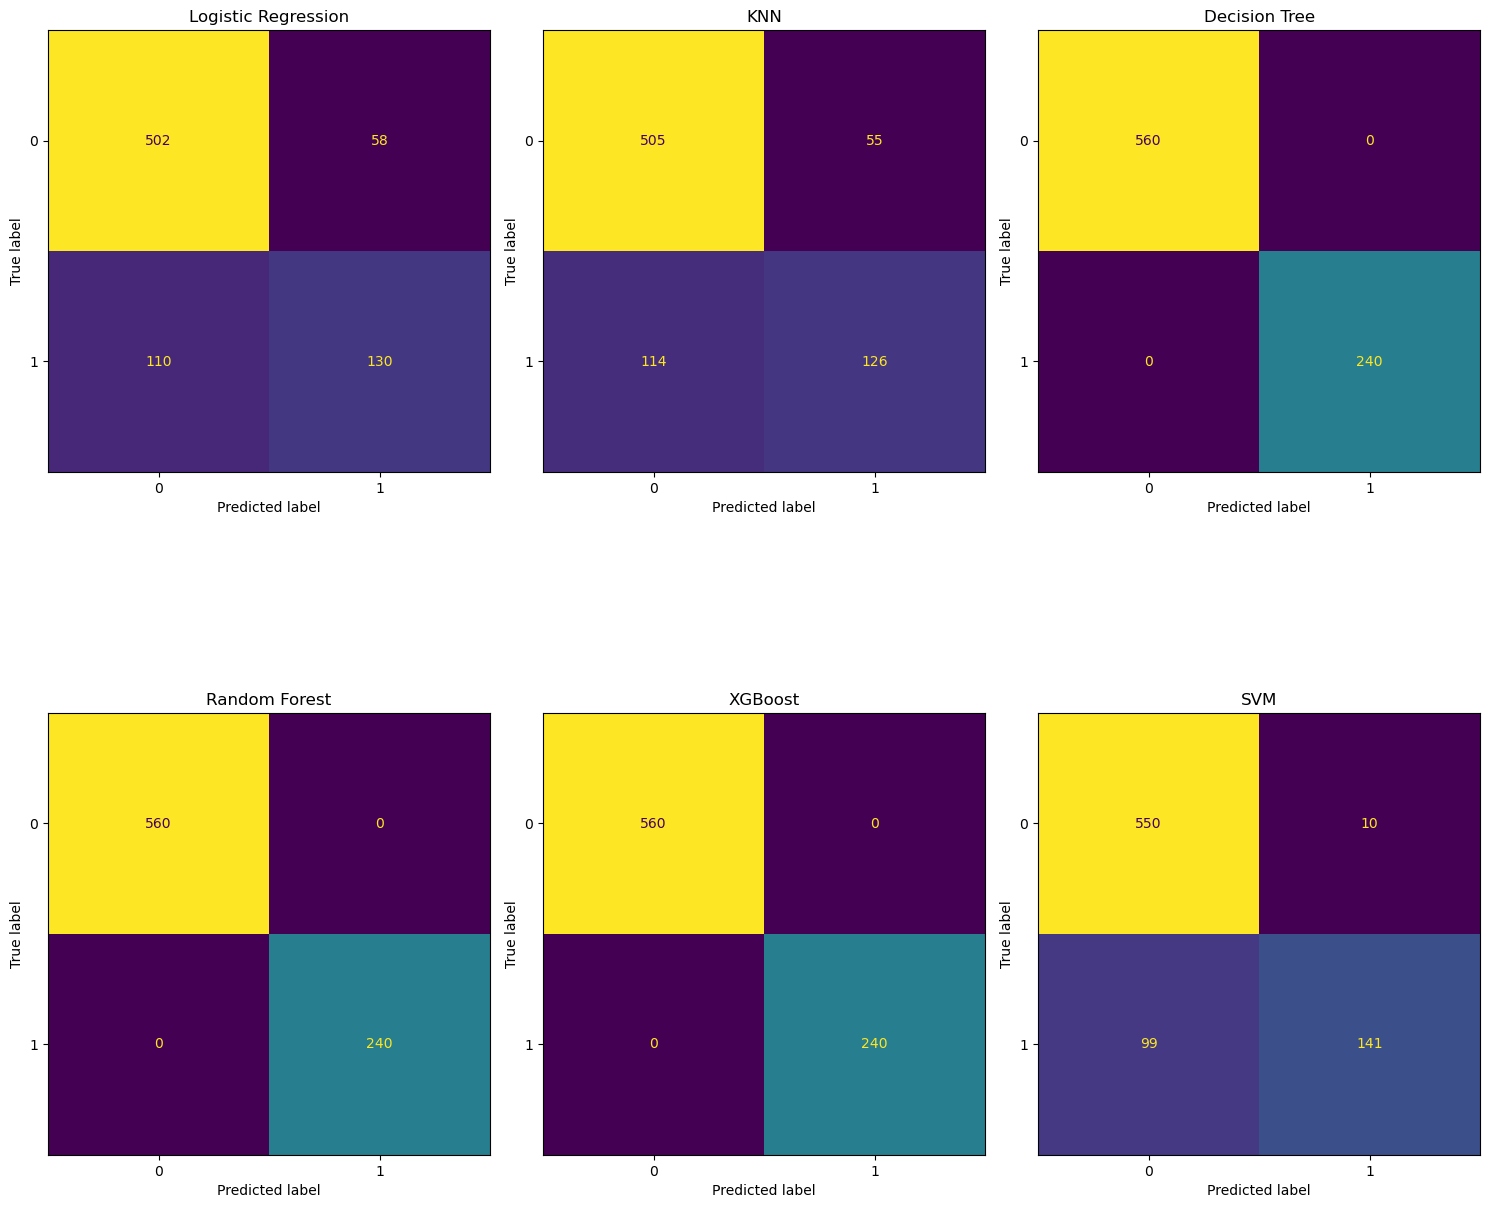

In [25]:
fig, axes = plt.subplots(2,3, figsize = (15,15))
for ax, model, name in zip(axes.flat, pipes, names):
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, ax = ax, colorbar = False)
    ax.set_title(name)    
plt.tight_layout()

In [26]:
def summarize_on_test (df: pd.DataFrame):
    return {
        "roc_auc_mean": df["test_roc_auc"].mean(),
        "roc_auc_std":  df["test_roc_auc"].std(),

        'pr-auc_mean': df['test_avg_precision'].mean(),
        'pr-auc_std': df['test_avg_precision'].std(),

        "recall_1_mean": df["test_recall_1"].mean(),  
        "recall_1_std":  df["test_recall_1"].std(),

        "recall_0_mean": df["test_recall_0"].mean(),      
        "recall_0_std":  df["test_recall_0"].std(),

        "precision_1_mean": df["test_precision_1"].mean(), 
        "precision_1_std":  df["test_precision_1"].std(),

    }
    

In [108]:
summarize = {}
for i, name in enumerate(names):
    summarize[name] = summarize_on_test(train_scores[i])

In [110]:
pd.DataFrame(summarize).T

,roc_auc_mean,roc_auc_std,pr-auc_mean,pr-auc_std,recall_1_mean,recall_1_std,recall_0_mean,recall_0_std,precision_1_mean,precision_1_std
Logistic Regression,0.781858,0.021445,0.604970,0.040128,0.472222,0.051434,0.866071,0.034580,0.606355,0.055573
KNN,0.692237,0.024751,0.457559,0.031719,0.372222,0.051555,0.849405,0.026328,0.515534,0.055488
Decision Tree,0.616270,0.035926,0.376865,0.029620,0.469444,0.066287,0.763095,0.030347,0.459104,0.047693
Random Forest,0.760510,0.028196,0.564254,0.047398,0.318056,0.059171,0.912500,0.021397,0.610372,0.065624
XGBoost,0.768738,0.037600,0.585680,0.052011,0.470833,0.079448,0.841071,0.039239,0.562564,0.053559
SVM,0.771838,0.027961,0.581589,0.043433,0.322222,0.056709,0.913690,0.022300,0.618595,0.071607


In [29]:
def overfitting(df:pd.DataFrame):
    return{"roc_auc_mean": df["train_roc_auc"].mean() - df["test_roc_auc"].mean(),
          'pr-auc_mean': df['train_avg_precision'].mean() - df['test_avg_precision'].mean() ,
          "recall_1_mean": df["train_recall_1"].mean() - df["test_recall_1"].mean(),
          "recall_0_mean": df["train_recall_0"].mean() - df["test_recall_0"].mean(),
          "precision_1_mean": df["train_precision_1"].mean() - df["test_precision_1"].mean()}

In [30]:
over = {}
for i, name in enumerate(names):
    over[name] = overfitting(train_scores[i])

In [31]:
pd.DataFrame(over).T

,roc_auc_mean,pr-auc_mean,recall_1_mean,recall_0_mean,precision_1_mean
Logistic Regression,0.068763,0.123399,0.089583,0.033036,0.098499
KNN,0.162494,0.206666,0.154861,0.056994,0.192221
Decision Tree,0.383730,0.623135,0.530556,0.236905,0.540896
Random Forest,0.239490,0.435746,0.681944,0.087500,0.389628
XGBoost,0.231262,0.414320,0.529167,0.158929,0.437436
SVM,0.177574,0.328036,0.258333,0.070982,0.323774


## Class_weight = 'balanced' models

### Training

In [31]:
from collections import Counter

In [34]:
counter = Counter(y_train)

In [35]:
scale_pos_weight = counter[0]/counter[1]

In [36]:
algos_cw = [LogisticRegression(random_state = 42, class_weight = 'balanced', solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42, class_weight = 'balanced'), 
         RandomForestClassifier(random_state =42, class_weight = 'balanced'), 
         XGBClassifier(random_state =42, scale_pos_weight = scale_pos_weight), 
         SVC(random_state = 42, probability=True, class_weight = 'balanced')]

In [37]:
pipes_cw = []
for algo in algos_cw:
    pipes_cw.append(Pipeline([('transformer', transformer), ('clf', algo)]))

In [33]:
from scipy.stats import loguniform, uniform, randint

In [39]:
pd_rl = {'clf__penalty': ['l1', 'l2', 'elasticnet'],
        'clf__C': loguniform(1e-3, 1e3),
         'clf__l1_ratio': uniform(0,1)
        }
pd_knn = {'clf__n_neighbors': randint(1, 51),
          "clf__weights": ["uniform", "distance"],
          "clf__p": randint(1, 2)
         }
pd_dt = {'clf__max_depth': randint(1,16),
         'clf__min_samples_split': randint(2,16),
         'clf__min_samples_leaf': randint(1,21),
         'clf__ccp_alpha':loguniform(1e-5, 1e-1),
         'clf__max_leaf_nodes': randint(2,16)
        }
pd_rf = {'clf__n_estimators': randint(50, 501),
         'clf__max_depth': randint(1,10),
         'clf__min_samples_leaf': randint(1,16),
         'clf__max_features': ['sqrt','log2']
        }
pd_xgb = {'clf__colsample_bytree': uniform(0, 1),
          'clf__subsample': uniform(0, 1),
          'clf__learning_rate': loguniform(1e-4, 1e0),
          'clf__max_depth': randint(1,10),
          'clf__n_estimators': randint(50, 501),
          'clf__reg_alpha': loguniform(1e-4, 1e1),
          'clf__reg_lambda': loguniform(1e-4, 1e2),
          'clf__gamma': loguniform(1e-8, 1e1)
         }
pd_svm = {'clf__kernel': ['rbf', 'poly', 'sigmoid'],
          'clf__C': loguniform(1e-3, 1e3),
          'clf__gamma': loguniform(1e-4, 1e0),
          'clf__degree': randint(2,6)
         }
param_distributions = [pd_rl, pd_knn, pd_dt, pd_rf, pd_xgb, pd_svm]

In [112]:
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
outer_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2)

In [148]:
n_iters = [50, 50, 50, 200, 300, 200]
results = {
    'Logistic Regression':[],
    'KNN':[], 
    'Decision Tree':[], 
    'Random Forest':[], 
    'XGBoost':[], 
    'SVM': []   
}
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [35]:
from sklearn.metrics import roc_auc_score, average_precision_score

In [152]:
for model, param, n, name in zip(pipes_cw, param_distributions, n_iters, names):
    for fold_id, (train, test) in enumerate(outer_cv.split(X_train, y_train)):
        X_tr, X_te = X_train.iloc[train], X_train.iloc[test]
        y_tr, y_te = y_train.iloc[train], y_train.iloc[test]
        r_s = RandomizedSearchCV(model, param_distributions = param, n_iter = n, refit = 'roc_auc', scoring = scoring, n_jobs = -1, random_state = 42)
        r_s.fit(X_tr, y_tr)
        best_model = r_s.best_estimator_
        best_params = r_s.best_params_
        p_te = best_model.predict_proba(X_te)[:,1]
        y_pred = best_model.predict(X_te)
        metrics = {
            "roc_auc": roc_auc_score(y_te, p_te),
            "avg_precision": average_precision_score(y_te, p_te),
            "recall_1": recall_score(y_te, y_pred, pos_label=1),
            "precision_1": precision_score(y_te, y_pred, pos_label=1, zero_division=0),
            "recall_0": recall_score(y_te, y_pred, pos_label=0),
        }
        results[name].append({
        "fold": fold_id,
        "metrics": metrics,
        "params": best_params
})

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175:

In [ ]:
import joblib
joblib.dump(results, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results.joblib')

### Results summary

In [37]:
import joblib
results_cw = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results.joblib')

In [41]:
results_cw

{'Logistic Regression': [{'fold': 0,
   'metrics': {'roc_auc': 0.7375372023809523,
    'avg_precision': 0.5538777882160022,
    'recall_1': 0.6875,
    'precision_1': 0.4714285714285714,
    'recall_0': 0.6696428571428571},
   'params': {'clf__C': 0.6812233896860297,
    'clf__l1_ratio': 0.1195942459383017,
    'clf__penalty': 'l2'}},
  {'fold': 1,
   'metrics': {'roc_auc': 0.7680431547619048,
    'avg_precision': 0.5697553791714732,
    'recall_1': 0.6458333333333334,
    'precision_1': 0.5254237288135594,
    'recall_0': 0.75},
   'params': {'clf__C': 0.6812233896860297,
    'clf__l1_ratio': 0.1195942459383017,
    'clf__penalty': 'l2'}},
  {'fold': 2,
   'metrics': {'roc_auc': 0.8255208333333333,
    'avg_precision': 0.6903964367369773,
    'recall_1': 0.7708333333333334,
    'precision_1': 0.5285714285714286,
    'recall_0': 0.7053571428571429},
   'params': {'clf__C': 0.5450293694558254,
    'clf__l1_ratio': 0.7851759613930136,
    'clf__penalty': 'elasticnet'}},
  {'fold': 3,
   

In [169]:
metrics = ['roc_auc', 'avg_precision', 'recall_1', 'precision_1', 'recall_0']
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [231]:
summary_cw = {}
for name in names:
    mets = {}
    for metric in metrics:
        value = [] 
        for fold in range(5):
            value.append(results_cw[name][fold]['metrics'][metric])
        mets[metric] = value
    summary_cw[name] = mets

In [233]:
final_cw_summary = {}
for name in names:
    values = {}
    for metric in metrics:
        values[f'{metric}_mean'] = np.mean(summary_cw[name][metric])
        values[f'{metric}_std'] = np.std(summary_cw[name][metric])                         
    final_cw_summary[name] = values

In [235]:
df_cw = pd.DataFrame(final_cw_summary).T

In [237]:
df_cw

,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,recall_1_mean,recall_1_std,precision_1_mean,precision_1_std,recall_0_mean,recall_0_std
Logistic Regression,0.768006,0.034468,0.583066,0.065811,0.695833,0.048591,0.510135,0.033971,0.712500,0.032635
KNN,0.739732,0.035326,0.517374,0.025239,0.145833,0.029463,0.562704,0.097126,0.950000,0.016560
Decision Tree,0.686328,0.036871,0.432139,0.037869,0.741667,0.031180,0.434157,0.024194,0.583929,0.040955
Random Forest,0.767597,0.024329,0.579921,0.035425,0.633333,0.033850,0.504760,0.035393,0.730357,0.044248
XGBoost,0.765551,0.035318,0.569583,0.051075,0.675000,0.064010,0.493114,0.050541,0.700000,0.048445
SVM,0.779353,0.027433,0.603919,0.057245,0.712500,0.073834,0.525191,0.017280,0.723214,0.036158


## Undersampling models

In [240]:
from imblearn.under_sampling import RandomUnderSampler